In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

D:\Anaconda\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# Load Model (Modern Format)
model = load_model("D:/PomegranateGuard/model/transformer_model.keras")

# Load Dataset
X_val = np.load("D:/PomegranateGuard/dataset/X_val.npy")
y_val = np.load("D:/PomegranateGuard/dataset/y_val.npy")

X_val = X_val.astype('float32') / 255.0

print("Evaluation Data Loaded")

Evaluation Data Loaded


In [3]:
# Predict
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
accuracy = accuracy_score(y_val, y_pred)
print("Validation Accuracy:", accuracy)


27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step
Validation Accuracy: 0.3578199052132701


In [4]:
# Classification Report
report = classification_report(y_val, y_pred)
print("\nClassification Report:\n")
print(report)

with open("D:/PomegranateGuard/evaluation/transformer_evaluation.txt", "w") as f:
    f.write("Validation Accuracy: " + str(accuracy) + "\n\n")
    f.write(report)

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)



Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       217
           1       0.00      0.00      0.00       150
           2       0.00      0.00      0.00       175
           3       0.36      1.00      0.53       302

    accuracy                           0.36       844
   macro avg       0.09      0.25      0.13       844
weighted avg       0.13      0.36      0.19       844



D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


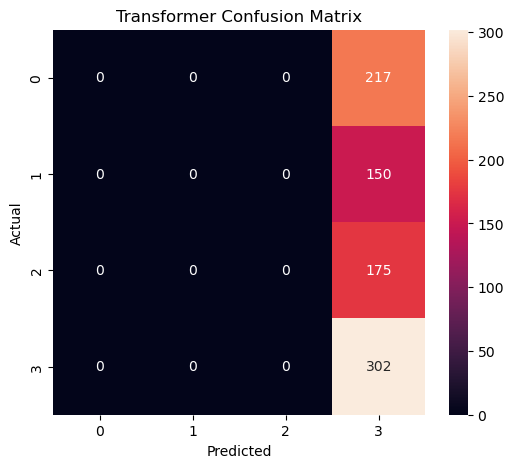

Evaluation Completed Successfully


In [5]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Transformer Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("D:/PomegranateGuard/evaluation/transformer_confusion_matrix.png")
plt.show()

print("Evaluation Completed Successfully")